Conectando a la NOAA para Receta Base Snow/Ice RGB (2026-07-06 14:00:00 UTC)...
Cargando desde disco...
Calibrando componentes físicos del Day Snow-Fog RGB según el estándar CIRA...
Carimbo y logos adaptados correctamente.
¡Producto Day Snow-Fog de borde a borde (Borderless) generado con éxito!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_DaySnowFog_SENAMHI_Bolivia_Full_20260706_1405.png


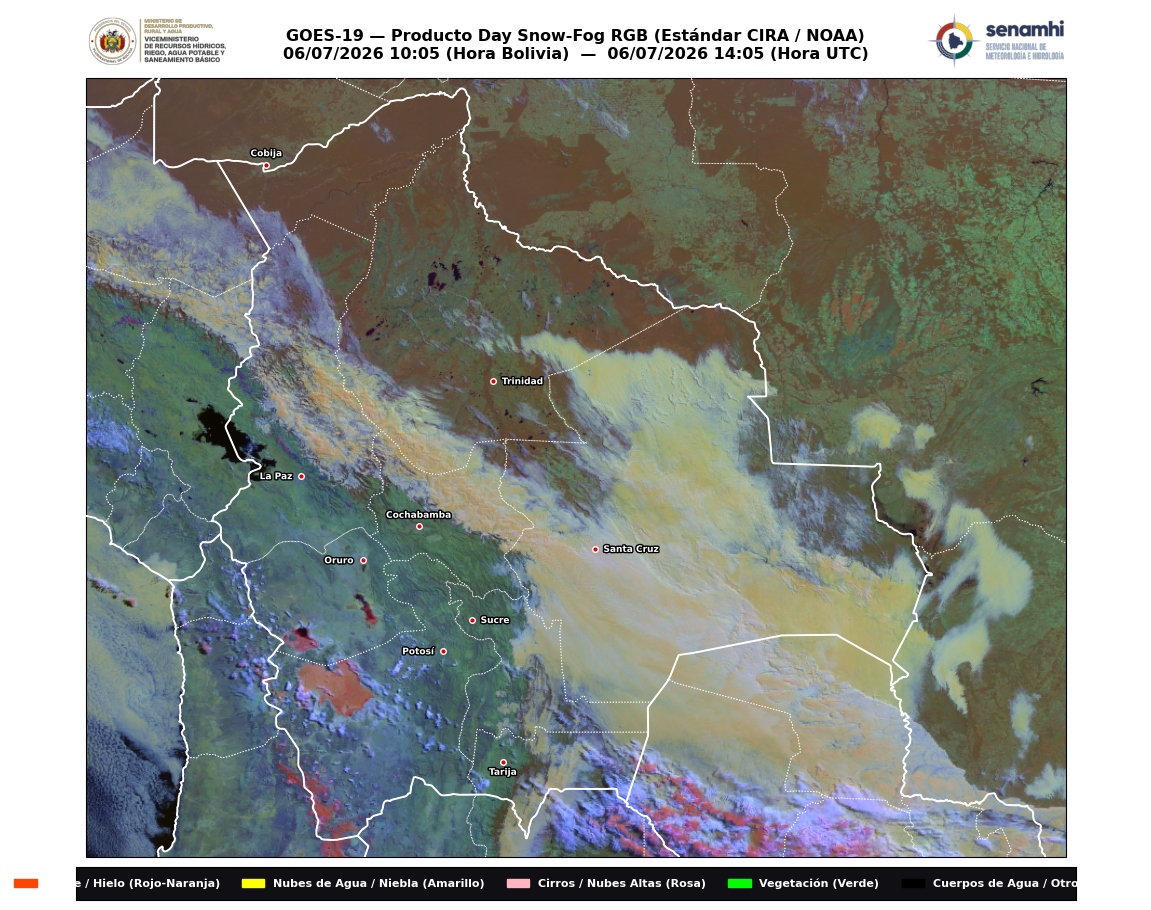

In [9]:
import os
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import s3fs

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO
# ==========================================
FECHA_BUSCADA = datetime(2026, 7, 6, 14, 00) 

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# ==========================================
# 2. CONEXIÓN A AMAZON S3
# ==========================================
print(f"Conectando a la NOAA para Receta Base Snow/Ice RGB ({FECHA_BUSCADA} UTC)...")
fs = s3fs.S3FileSystem(anon=True)

doy = FECHA_BUSCADA.strftime('%j') 
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora}/"

try:
    archivos = fs.ls(s3_folder)
    archivos_multi = [f for f in archivos if f.endswith('.nc')]
    
    if not archivos_multi:
        print(f"⚠️ Alerta: No hay datos en la hora {hora}. Intentando buscar un bloque antes...")
        hora_alterna = f"{int(hora)-1:02d}"
        s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora_alterna}/"
        archivos = fs.ls(s3_folder)
        archivos_multi = [f for f in archivos if f.endswith('.nc')]
        
    s3_path = archivos_multi[0]
    file_name = s3_path.split('/')[-1]
    local_path = os.path.join(RAW_DATA, file_name)
    
    if not os.path.exists(local_path):
        print(f"Descargando archivo multibanda: {file_name}...")
        fs.get(s3_path, local_path)
    else:
        print("Cargando desde disco...")
        
    ds = xr.open_dataset(local_path)

except Exception as e:
    print(f"Error crítico: {e}")
    raise e

# ==========================================
# 3. PROYECCIÓN SATELITAL
# ==========================================
glob_attrs = ds.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, satellite_height=height, sweep_axis=sweep)

# ==========================================
# 4. RECETA ESPECTRAL OFICIAL CIRA: DAY SNOW-FOG RGB (SINFÍN DE COLOR)
# ==========================================
print("Calibrando componentes físicos del Day Snow-Fog RGB según el estándar CIRA...")

ch03_raw = ds['CMI_C03'].data.astype(float)  # 0.86 µm
ch05_raw = ds['CMI_C05'].data.astype(float)  # 1.60 µm
ch07_raw = ds['CMI_C07'].data.astype(float)  # 3.90 µm
ch13_raw = ds['CMI_C13'].data.astype(float)  # 10.30 µm

ch03_pct = ch03_raw if np.max(ch03_raw) > 1.0 else ch03_raw * 100.0
ch05_pct = ch05_raw if np.max(ch05_raw) > 1.0 else ch05_raw * 100.0

# Rojo (Canal 3)
R_min, R_max = 0.0, 100.0
R = (ch03_pct - R_min) / (R_max - R_min)
R = np.clip(R, 0, 1)
R = np.power(R, 1.0 / 1.7)

# Verde (Canal 5)
G_min, G_max = 0.0, 70.0
G = (ch05_pct - G_min) / (G_max - G_min)
G = np.clip(G, 0, 1)
G = np.power(G, 1.0 / 1.7)

# Azul (Ch07 - Ch13)
blue_diff = ch07_raw - ch13_raw
B_min, B_max = 0.0, 30.0
B = (blue_diff - B_min) / (B_max - B_min)
B = np.clip(B, 0, 1)
B = np.power(B, 1.0 / 1.7)

rgb_image = np.dstack((R, G, B))

# ==========================================
# 5. GENERACIÓN DEL PRODUCTO VISUAL (BORDERLESS ABSOLUTO)
# ==========================================
# Configuración del lienzo idéntico al Infrarrojo
fig, ax = plt.subplots(figsize=(10, 9.5), facecolor='white', subplot_kw={'projection': ccrs.PlateCarree()})

# El secreto del Infrarrojo: ajustar márgenes externos de la figura al extremo (0.01 left, 0.99 right)
fig.subplots_adjust(left=0.01, right=0.99, top=0.88, bottom=0.06)

# --- AJUSTE GEOGRÁFICO EQUILIBRADO (BOLIVIA CENTRADA) ---
ax.set_extent([-71.8, -55.2, -23.2, -9.5], crs=ccrs.PlateCarree())

# --- TRUCO BORDERLESS REPLICADO ---
# Forzamos a que la imagen ignore la relación de aspecto nativa del disco y se adapte al extent
# Pasamos la matriz RGB usando 'color' dentro de pcolormesh evaluando la grilla exacta de x e y
X_grid = ds.x.data * height
Y_grid = ds.y.data * height

# pcolormesh requiere un array de color aplanado para RGB, pero imshow con aspect='auto' es más rápido y exacto
x_min, x_max = X_grid.min(), X_grid.max()
y_min, y_max = Y_grid.min(), Y_grid.max()

# aspect='auto' es el verdadero truco que estira la imagen satelital para rellenar los bordes laterales vacíos
ax.imshow(rgb_image, origin='upper', transform=dataprojenv, 
          extent=[x_min, x_max, y_min, y_max], aspect='auto', zorder=1)

# --- CAPA 2: LÍMITES GEOGRÁFICOS PERFECTAMENTE ALINEADOS ---
COLOR_BLANCO = '#ffffff'
ax.add_feature(cfeature.COASTLINE, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(cfeature.STATES, linestyle=(0, (1, 2)), edgecolor=COLOR_BLANCO, linewidth=0.7, zorder=4)

# --- CAPA 3: LAS 9 CAPITALES DE DEPARTAMENTO DE BOLIVIA ---
capitales = {
    "Cobija":       {"lat": -11.02, "lon": -68.74, "pos": "top"},
    "Trinidad":     {"lat": -14.83, "lon": -64.90, "pos": "right"},
    "La Paz":       {"lat": -16.50, "lon": -68.15, "pos": "left"},
    "Cochabamba":   {"lat": -17.38, "lon": -66.16, "pos": "top"},
    "Santa Cruz":   {"lat": -17.78, "lon": -63.18, "pos": "right"},
    "Oruro":        {"lat": -17.98, "lon": -67.11, "pos": "left"},
    "Sucre":        {"lat": -19.03, "lon": -65.26, "pos": "right"},
    "Potosí":       {"lat": -19.58, "lon": -65.75, "pos": "left"},
    "Tarija":       {"lat": -21.53, "lon": -64.73, "pos": "bottom"}
}

for ciudad, info in capitales.items():
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', markersize=4, markeredgecolor='white', markeredgewidth=1.0, transform=ccrs.PlateCarree(), zorder=10)
    offset_lon = 0.15 if info["pos"] == "right" else (-0.15 if info["pos"] == "left" else 0)
    offset_lat = 0.15 if info["pos"] == "top" else (-0.22 if info["pos"] == "bottom" else -0.05)
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad, color='white', fontsize=6.5, fontweight='bold', horizontalalignment=alignment_h, transform=ccrs.PlateCarree(), zorder=11, path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 4: PROCESAMIENTO DE FECHAS ---
fecha_utc = datetime.strptime(ds.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)
string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

# --- CAPA 5: TÍTULO CORPORATIVO ADAPTADO ---
ax.set_title(f"GOES-19 — Producto Day Snow-Fog RGB (Estándar CIRA / NOAA)\n{string_bot}  —  {string_utc}", fontsize=11.5, fontweight='bold', pad=14, loc='center', linespacing=1.3)

# --- CAPA 6: LEYENDA CORPORATIVA HORIZONTAL FIJA (UBICACIÓN IDÉNTICA) ---
pos_mapa = ax.get_position()
ax_leyenda = fig.add_axes([0.00, pos_mapa.y0 - 0.045, 1.00, 0.035]) # Forzamos ancho completo 0.00 a 1.00 igual al IR
ax_leyenda.set_facecolor('#0f0f14')
ax_leyenda.set_xticks([])
ax_leyenda.set_yticks([])

parches_leyenda = [
    mpatches.Patch(color='#ff4500', label='Nieve / Hielo (Rojo-Naranja)'), 
    mpatches.Patch(color='#ffff00', label='Nubes de Agua / Niebla (Amarillo)'),
    mpatches.Patch(color='#ffb6c1', label='Cirros / Nubes Altas (Rosa)'),
    mpatches.Patch(color='#00ff00', label='Vegetación (Verde)'),
    mpatches.Patch(color='#000000', label='Cuerpos de Agua / Otros (Negro)')
]

leyenda = ax_leyenda.legend(handles=parches_leyenda, loc='center', ncol=5, frameon=False, fontsize=8.0)

for text in leyenda.get_texts():
    text.set_color('white')
    text.set_weight('bold')

# --- CAPA 7: INSERCIÓN DE LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
        print("Carimbo y logos adaptados correctamente.")
except Exception as e:
    print(f"Alerta logos: {e}")

output_name = f"{OUTPUTS}/GOES19_DaySnowFog_SENAMHI_Bolivia_Full_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"
# Guardamos con pad_inches idéntico al IR
plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.03)
print(f"¡Producto Day Snow-Fog de borde a borde (Borderless) generado con éxito!: {output_name}")

plt.show()